In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01000
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  2599.0055748837894
RUN  2 , total integrated cost =  1287.8807847844528
RUN  3 , total integrated cost =  834.2167149260226
RUN  4 , total integrated cost =  471.486468816486
RUN  5 , total integrated cost =  329.57724744207735
RUN  6 , total integrated cost =  223.49892229482933
RUN  7 , total integrated cost =  178.27778676545316
RUN  8 , total integrated cost =  144.36909039720723
RUN  9 , total integrated cost =  123.7928986627459
RUN  10 , total integrated cost =  80.08421748664102
RUN  11 , total integrated cost =  71.12530011880153
RUN  12 , total integrated cost =  64.53831621952054
RUN  13 , total integrated cost =  61.12801566186394
RUN  14 , total integrated cost =  58.406572555516185
RUN  15 , total integrated cost =  56.8050756327088
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  648 , total integrated cost =  25.82394822274214
Improved over  648  iterations in  24.615927051752806  seconds by  99.80600178172268  percent.
Problem in initial value trasfer:  Vmean_exc -56.672350700720436 -56.67235079608464
weight =  5154.686516607908
set cost params:  1.0 5154.686516607908 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13298.800507053313
Gradient descend method:  None
RUN  1 , total integrated cost =  12847.767786480617
RUN  2 , total integrated cost =  12845.824408123472
RUN  3 , total integrated cost =  12845.247261087243
RUN  4 , total integrated cost =  12841.992833118995
RUN  5 , total integrated cost =  12816.699416138648
RUN  6 , total integrated cost =  12811.211597356609
RUN  7 , total integrated cost =  12810.838565427135
RUN  8 , total integrated cost =  12810.45728888999
RUN  9 , total integrated cost =  12804.707564862181
RUN  10 , total integrated cost =  12780.847842194717
RUN  11 , 

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  12697.606641107304
Control only changes marginally.
RUN  50 , total integrated cost =  12697.606641107304
Improved over  50  iterations in  1.084713539108634  seconds by  4.520662338134571  percent.
Problem in initial value trasfer:  Vmean_exc -56.67195630182014 -56.67196495848285
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  2413.0944104899118
RUN  2 , total integrated cost =  222.37940833206866
RUN  3 , total integrated cost =  194.42731951300283
RUN  4 , total integrated cost =  181.08395297596735
RUN  5 , total integrated cost =  166.72808624548838
RUN  6 , total integrated cost =  157.8163345494967
RUN  7 , total integrated cost =  147.5838607884009
RUN  8 , total integrated cost =  140.28195389463124
RUN  9 , total integrated cost =  131.63376894239468
RUN  

...

RUN  1 , total integrated cost =  19226.09831809435
Control only changes marginally.
RUN  1 , total integrated cost =  19226.09831809435
Improved over  1  iterations in  0.05382310412824154  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.50039590763683 -75.50039745428764
-------  121 0.5750000000000002 0.8250000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33632.4581250047
Gradient descend method:  None
RUN  1 , total integrated cost =  3693.0694765366716
RUN  2 , total integrated cost =  3106.3753270630486
RUN  3 , total integrated cost =  311.22553928706174
RUN  4 , total integrated cost =  182.5824046336898
RUN  5 , total integrated cost =  158.7263034236793
RUN  6 , total integrated cost =  146.30314999348482
RUN  7 , total integrated cost =  138.17230830846924
RUN  8 , total integrated cost =  131.8047490989861
RUN  9 , total integrated cost =  126.11622573056833
RUN  10 , total integrat

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  32527.353576111826
Control only changes marginally.
RUN  43 , total integrated cost =  32527.353576111786
Improved over  43  iterations in  0.9653872139751911  seconds by  3.214893861984919  percent.
Problem in initial value trasfer:  Vmean_exc -56.70343714365063 -56.70343702417049
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10117.573589110178
Gradient descend method:  None
RUN  1 , total integrated cost =  10117.573589110178
Control only changes marginally.
RUN  1 , total integrated cost =  10117.573589110178
Improved over  1  iterations in  0.04745818302035332  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10117.573589110178
Gradient descend method:  None
RUN  1 , total integrated cost =  10117.573589110178
Control only changes marginally.
RUN  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23430.768827434094
RUN  2 , total integrated cost =  23430.768827434087
RUN  3 , total integrated cost =  23430.768827434087
Control only changes marginally.
RUN  3 , total integrated cost =  23430.768827434087
Improved over  3  iterations in  0.10515036061406136  seconds by  4.7885777121337014e-08  percent.
Problem in initial value trasfer:  Vmean_exc -73.8354956279556 -73.8355115326311
weight =  10.000000004788578
set cost params:  1.0 10.000000004788578 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768827434087
Gradient descend method:  None
RUN  1 , total integrated cost =  23430.768827434087
Control only changes marginally.
RUN  1 , total integrated cost =  23430.768827434087
Improved over  1  iterations in  0.05554994381964207  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.8354956279556 -73.8355115326311


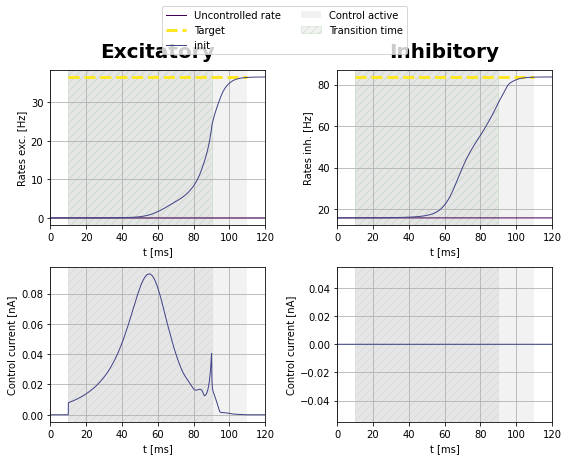

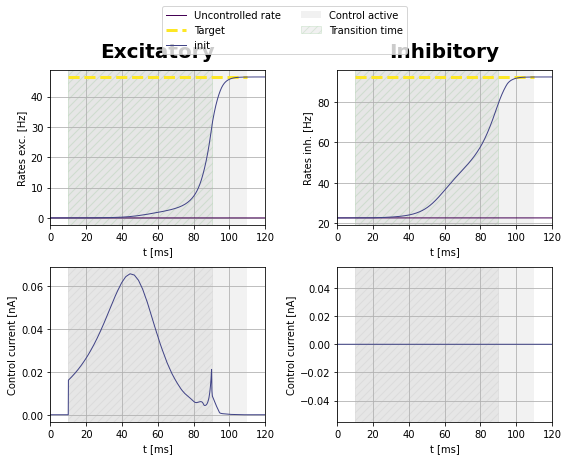

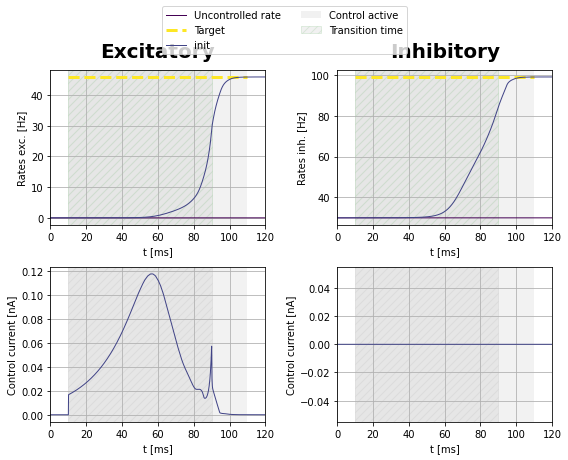

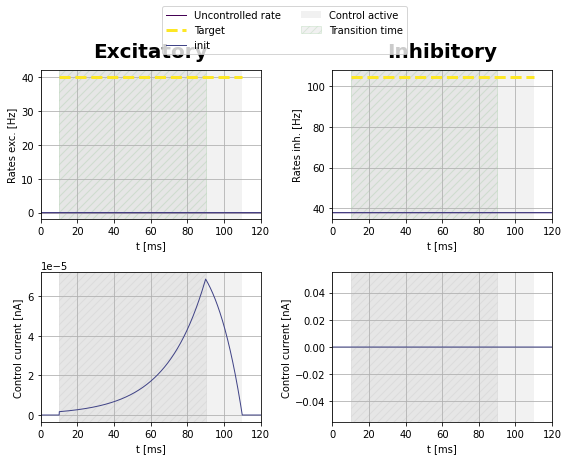

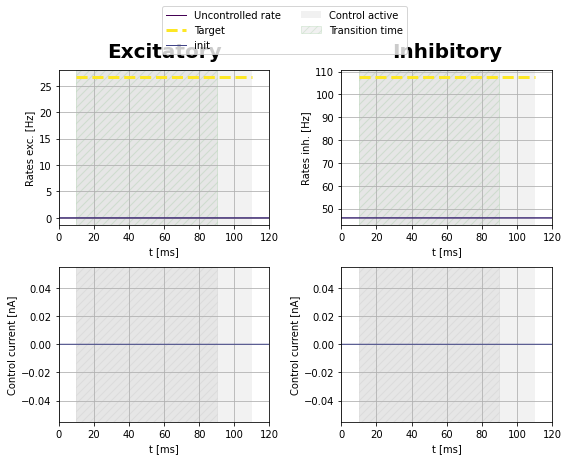

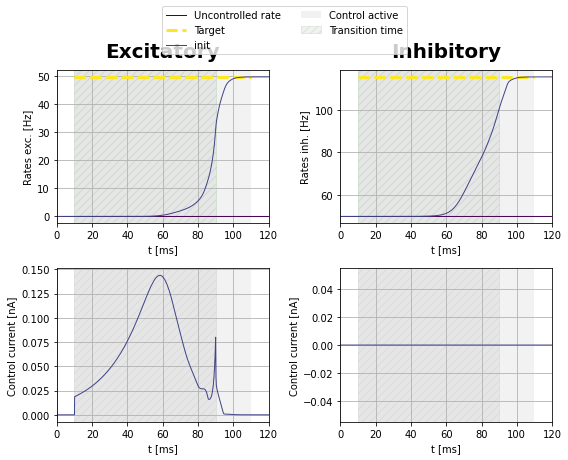

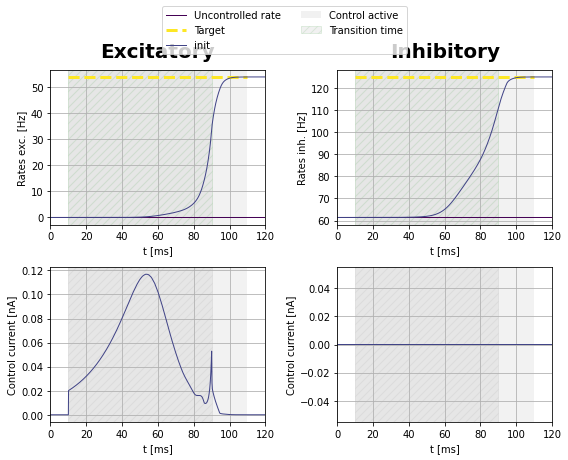

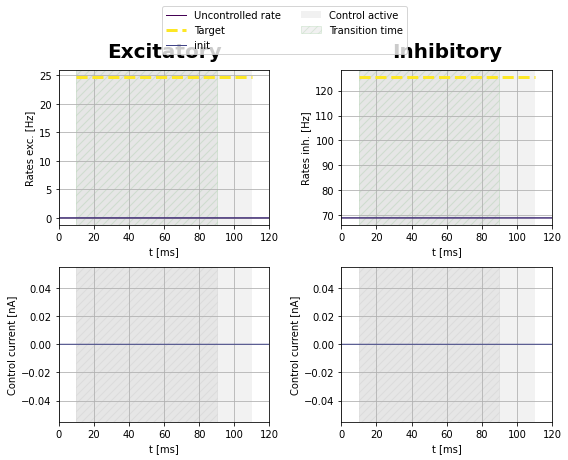

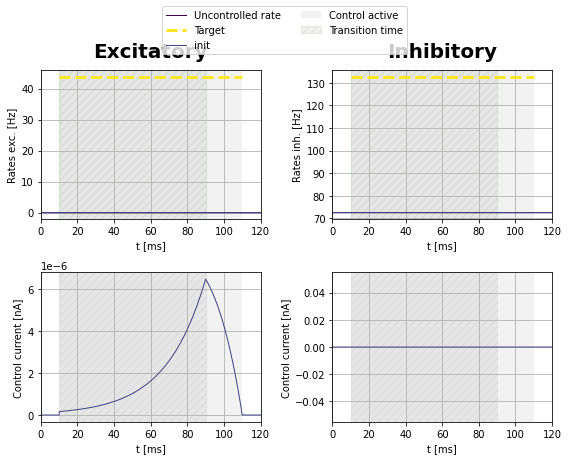

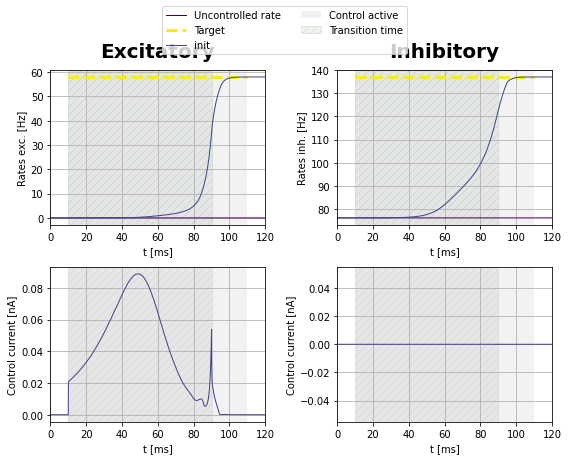

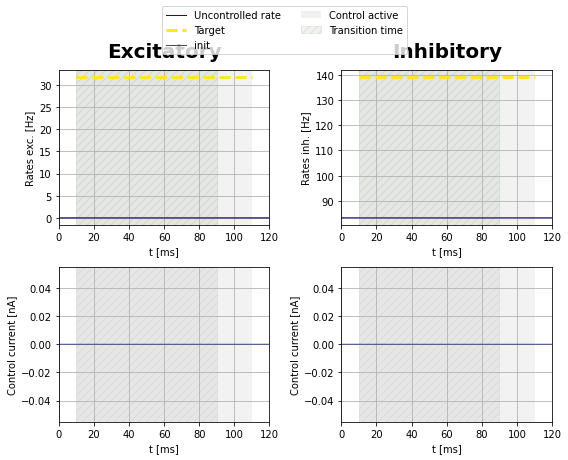

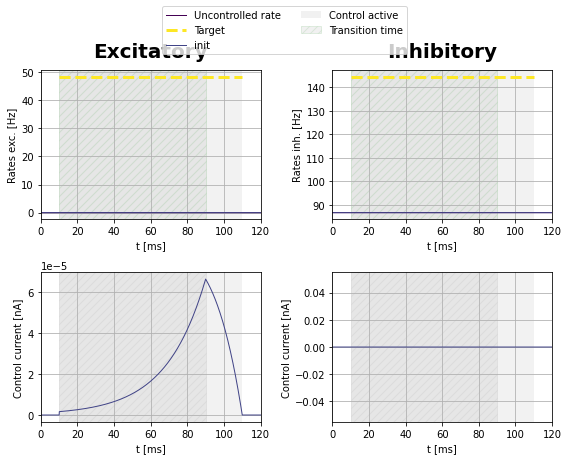

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
found solution for  22
-------

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  16137.019477864309
Control only changes marginally.
RUN  7 , total integrated cost =  16137.019477864309
Improved over  7  iterations in  0.1964440681040287  seconds by  0.2754060066361319  percent.
Problem in initial value trasfer:  Vmean_exc -73.7202714867781 -73.72028731286868
weight =  10.000000007435505
set cost params:  1.0 10.000000007435505 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019477864309
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019477864309
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019477864309
Improved over  1  iterations in  0.055937083438038826  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.7202714867781 -73.72028731286868
-------  55 0.4250000000000001 0.6250000000000003
[0, 11, 22, 33] []
closest index  33
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  19226.098318095304
Control only changes marginally.
RUN  6 , total integrated cost =  19226.098318095304
Improved over  6  iterations in  0.1615244410932064  seconds by  0.23837477713036037  percent.
Problem in initial value trasfer:  Vmean_exc -75.50042350789272 -75.50042492746942
weight =  10.000000000055252
set cost params:  1.0 10.000000000055252 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19226.098318095304
Gradient descend method:  None
RUN  1 , total integrated cost =  19226.098318095304
Control only changes marginally.
RUN  1 , total integrated cost =  19226.098318095304
Improved over  1  iterations in  0.053343841806054115  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.50042350789272 -75.50042492746942
-------  121 0.5750000000000002 0.8250000000000005
found solution for  121
-------  132 0.4500000000000001 0.8750000000000006
[0, 11, 22, 33, 66, 88, 121] []
closest index  121
set cos

...

RUN  6 , total integrated cost =  16137.019477943533
Control only changes marginally.
RUN  6 , total integrated cost =  16137.019477943533
Improved over  6  iterations in  0.16557700373232365  seconds by  0.17709605559511488  percent.
Problem in initial value trasfer:  Vmean_exc -73.72042577745927 -73.720440889093
weight =  10.00000000738641
set cost params:  1.0 10.00000000738641 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019477943533
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019477943533
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019477943533
Improved over  1  iterations in  0.052622465416789055  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.72042577745927 -73.720440889093
-------  55 0.4250000000000001 0.6250000000000003
[0, 11, 22, 33, 66, 88, 121] [33, 66, 88, 22, 11, 121]
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate ad

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  19226.098318095083
Control only changes marginally.
RUN  6 , total integrated cost =  19226.098318095083
Improved over  6  iterations in  0.16576779261231422  seconds by  0.04681414956711194  percent.
Problem in initial value trasfer:  Vmean_exc -75.50041869168406 -75.50042013343501
weight =  10.000000000055367
set cost params:  1.0 10.000000000055367 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19226.098318095083
Gradient descend method:  None
RUN  1 , total integrated cost =  19226.098318095083
Control only changes marginally.
RUN  1 , total integrated cost =  19226.098318095083
Improved over  1  iterations in  0.05380994454026222  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.50041869168406 -75.50042013343501
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
[0, 11, 22, 33, 66, 88, 121] [121, 88, 66, 33, 22, 11]
closest index  0
set cost p

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  23430.768827541833
Control only changes marginally.
RUN  5 , total integrated cost =  23430.768827541833
Improved over  5  iterations in  0.14676482416689396  seconds by  0.03827953913388171  percent.
Problem in initial value trasfer:  Vmean_exc -73.83579110455734 -73.83580564360115
weight =  10.000000004742594
set cost params:  1.0 10.000000004742594 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768827541833
Gradient descend method:  None
RUN  1 , total integrated cost =  23430.768827541833
Control only changes marginally.
RUN  1 , total integrated cost =  23430.768827541833
Improved over  1  iterations in  0.05370590277016163  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.83579110455734 -73.83580564360115
------------------------------------------------------------
-------------------- 7
------------------------------------------------------------
found solution:  [0, 11, 22, 33, 66, 88

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5402.87495254357
set cost params:  1.0 5402.87495254357 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13298.06342552668
Gradient descend method:  None
RUN  1 , total integrated cost =  13297.925125926242
RUN  2 , total integrated cost =  13297.914610865664
RUN  3 , total integrated cost =  13297.91143390509
RUN  4 , total integrated cost =  13297.910597379385
RUN  5 , total integrated cost =  13297.910425974047
RUN  6 , total integrated cost =  13297.910412928557


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  13297.910412767545
RUN  8 , total integrated cost =  13297.91041276752
RUN  9 , total integrated cost =  13297.91041276752
Control only changes marginally.
RUN  9 , total integrated cost =  13297.91041276752
Improved over  9  iterations in  0.27351779863238335  seconds by  0.0011506394146465482  percent.
Problem in initial value trasfer:  Vmean_exc -56.67193207857388 -56.67194131653679
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  14272.823388004514
set cost params:  1.0 14272.823388004514 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21550.58682525871
Gradient descend method:  None
RUN  1 , total integrated cost =  21550.293453114304
RUN  2 , total integrated cost =  21550.28835880918
RUN  3 , total integrated cost =  21550.288328360377


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  21550.288327323833
RUN  5 , total integrated cost =  21550.28832732377
RUN  6 , total integrated cost =  21550.28832732377
Control only changes marginally.
RUN  6 , total integrated cost =  21550.28832732377
Improved over  6  iterations in  0.2285198736935854  seconds by  0.0013851035118364052  percent.
Problem in initial value trasfer:  Vmean_exc -56.69835706286216 -56.69835816988409
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  4629.069073966328
set cost params:  1.0 4629.069073966328 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21054.232767730602
Gradient descend method:  None
RUN  1 , total integrated cost =  21054.129803934546
RUN  2 , total integrated cost =  21054.11963829168
RUN  3 , total integrated cost =  21054.117625896746
RUN  4 , total integrated cost =  21054.11738324974
RUN  5 , total integrated cost =  21054.117373662426
RUN  6 , total integrated cost =  21054.117373460653
RUN

...

RUN  3 , total integrated cost =  33629.555887933224
Control only changes marginally.
RUN  3 , total integrated cost =  33629.555887933224
Improved over  3  iterations in  0.17519592493772507  seconds by  1.7053025658242404e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.70343721869393 -56.70343709590061
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
[[True, True], [True, False], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for 

ERROR:root:Problem in initial value trasfer


0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  11587.459969557689
set cost params:  1.0 11587.459969557689 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33629.55588793322
Gradient descend method:  None
RUN  1 , total integrated cost =  33629.55588793322
Control only changes marginally.
RUN  1 , total integrated cost =  33629.55588793322
Improved over  1  iterations in  0.0759365912526846  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70343721869393 -56.70343709590061
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged fo

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  29121.149533064323
Control only changes marginally.
RUN  1 , total integrated cost =  29121.149533064323
Improved over  1  iterations in  0.08431268483400345  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70419324318793 -56.704193268728105
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, False], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  262.3634882735153
Gradient descend method:  None
RUN  1 , total integrated cost =  23.25339453182171
RUN  2 , total integrated cost =  22.807952901069616
RUN  3 , total integrated cost =  22.771021160484175
RUN  4 , total integrated cost =  22.74847480561687
RUN  5 , total integrated cost =  22.72929052585763
RUN  6 , total integrated cost =  22.72700847199034
RUN  7 , total integrated cost =  22.722409598084386
RUN  8 , total integrated cost =  22.720341286969457
RUN  9 , total integrated cost =  22.69493296042191
RUN  10 , total integrated cost =  22.69127761634689
RUN  11 , total integrated cost =  22.691109350605
RUN  12 , total integrated cost =  22.689115068137035
RUN  13 , total integrated cost =  22.688235961220595
RUN  14 , total integrated cost =  22.688142406791535
RUN  15 , total integrated cost =  22.685215488207074
RUN  

ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  22.6077240493154
Control only changes marginally.
RUN  101 , total integrated cost =  22.6077240493154
Improved over  101  iterations in  6.445136323571205  seconds by  91.38305249785873  percent.
Problem in initial value trasfer:  Vmean_exc -56.67235516724982 -56.67235507090096
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  241.17590689786823
Gradient descend method:  HS
RUN  1 , total integrated cost =  240.5263762674576
RUN  2 , total integrated cost =  239.63876012621952
RUN  3 , total integrated cost =  238.8913079555068
RUN  4 , total integrated cost =  238.84510222627048
RUN  5 , total integrated cost =  238.1142185797766
RUN  6 , total integrated cost =  237.0410905110368
RUN  7 , total integrated cost =  236.56596328401653
RUN  8 , total integrated cost =  236.3424830838893
RUN  9 , total integrated cost =  235.19961347041223
RUN  10 , total integrated cost =  234.2382343

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  110.93068902988048
RUN  1000 , total integrated cost =  110.93068902988048
Improved over  1000  iterations in  74.80516008473933  seconds by  54.004240947311224  percent.
Problem in initial value trasfer:  Vmean_exc -56.6723501573807 -56.67235030166101
weight =  11998.777417184683
set cost params:  1.0 11998.777417184683 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13293.039907275279
Gradient descend method:  None
RUN  1 , total integrated cost =  13118.909639907159
RUN  2 , total integrated cost =  13077.137084277927
RUN  3 , total integrated cost =  12966.31962970007
RUN  4 , total integrated cost =  12941.095036346876
RUN  5 , total integrated cost =  12908.074484322606
RUN  6 , total integrated cost =  12883.304633929536
RUN  7 , total integrated cost =  12848.444182782703
RUN  8 , total integrated cost =  12717.011138501672
RUN  9 , total integrated cost =  12424.892799955493
RUN  10 , total integrated cost =  124

...

RUN  6 , total integrated cost =  10069.778155368047
RUN  7 , total integrated cost =  10069.778155368047
Control only changes marginally.
RUN  7 , total integrated cost =  10069.778155368047
Improved over  7  iterations in  0.6658417321741581  seconds by  0.09395708982670214  percent.
Problem in initial value trasfer:  Vmean_exc -56.65214814508225 -56.652149823786424
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.782316755798
Gradient descend method:  None
RUN  1 , total integrated cost =  23430.769055043547
RUN  2 , total integrated cost =  23430.768839855504
RUN  3 , total integrated cost =  23430.768838666725
RUN  4 , total integrated cost =  23430.768838654538
RUN  5 , total integrated cost =  23430.768838654105
RUN  6 , total integrated cost =  23430.768838654094
RUN  7 , total integrated cost =  23430.768838654094
Control only changes marginally.
RUN  7 , total integr

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  23430.768837527427
Control only changes marginally.
RUN  3 , total integrated cost =  23430.768837527427
Improved over  3  iterations in  0.24924151599407196  seconds by  4.808498488273472e-09  percent.
Problem in initial value trasfer:  Vmean_exc -73.83859725612798 -73.83859882529269
weight =  99.0000000048085
set cost params:  1.0 99.0000000048085 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768837516884
Gradient descend method:  None
RUN  1 , total integrated cost =  23430.76883751688


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  23430.76883751688
Control only changes marginally.
RUN  2 , total integrated cost =  23430.76883751688
Improved over  2  iterations in  0.24802887625992298  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -73.83859725614657 -73.8385988253112


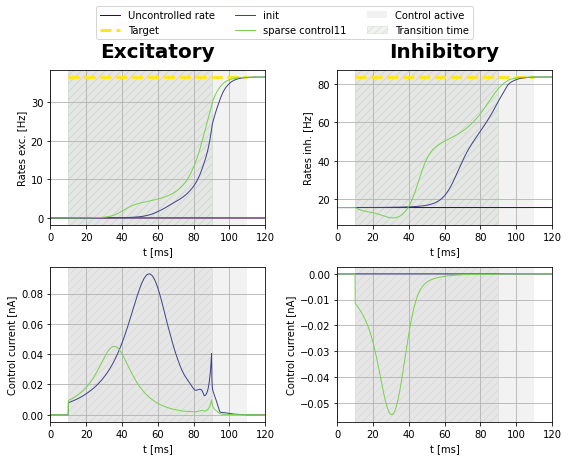

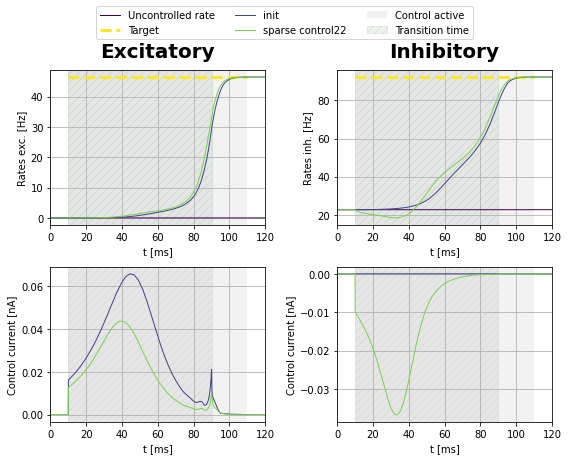

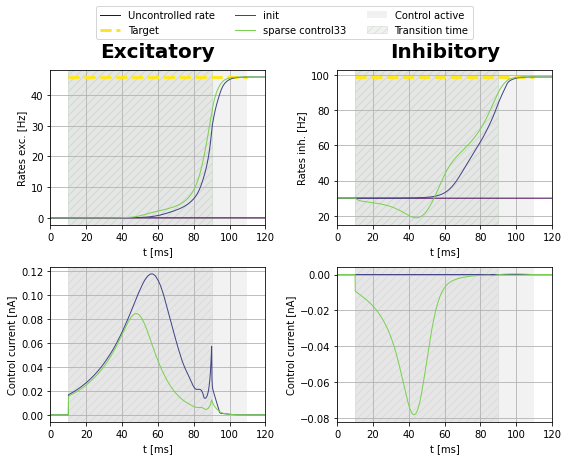

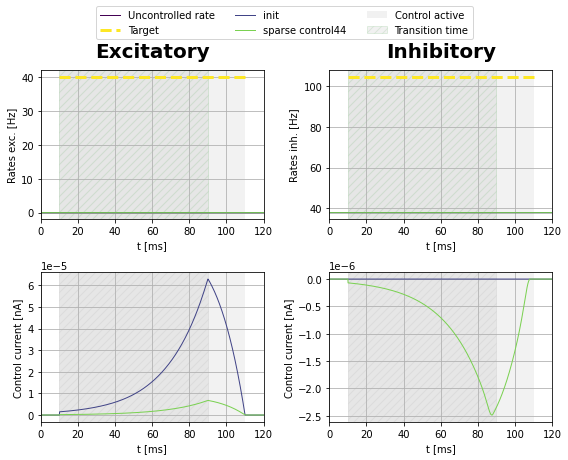

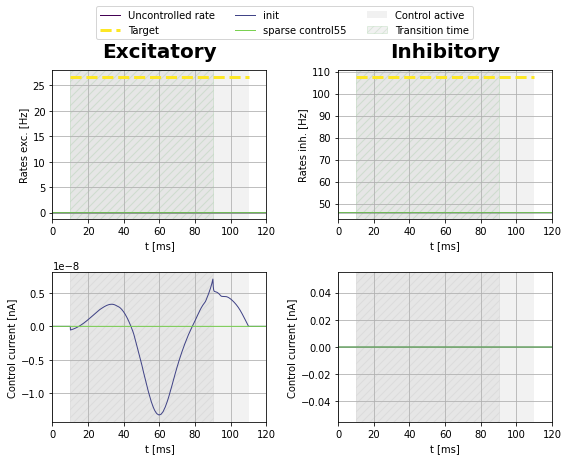

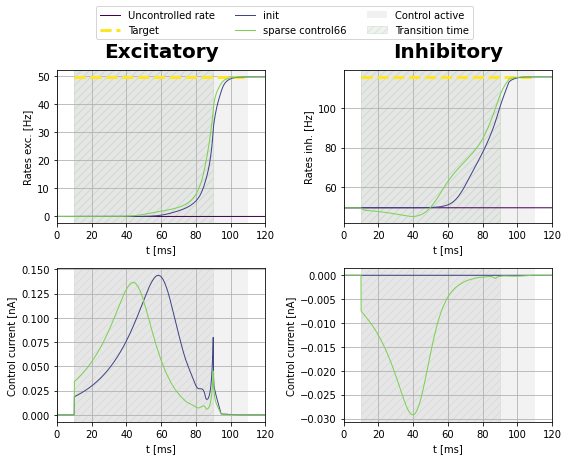

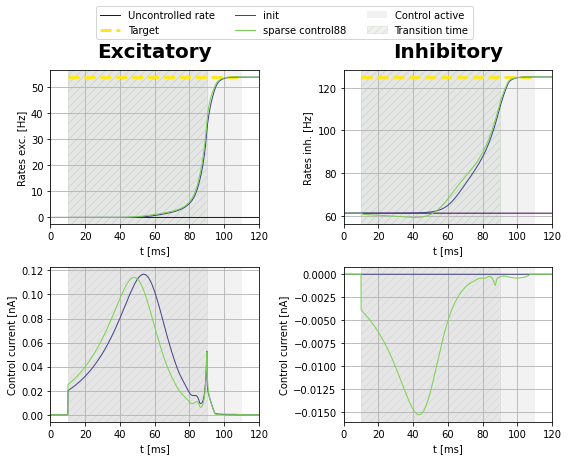

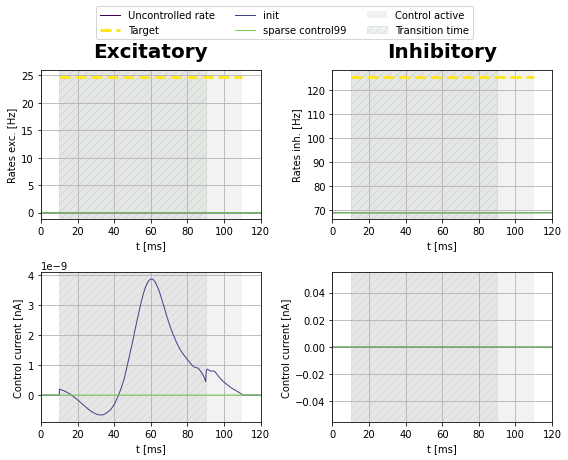

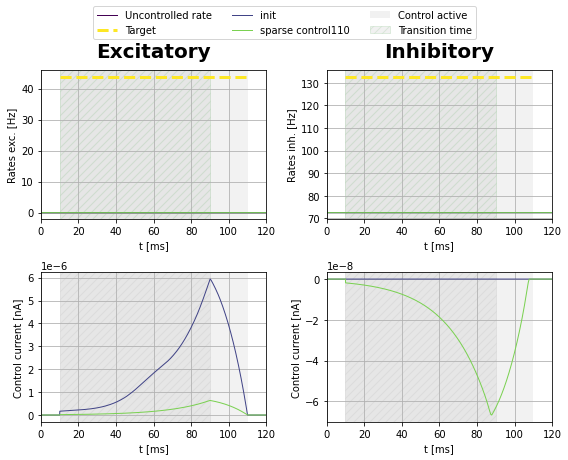

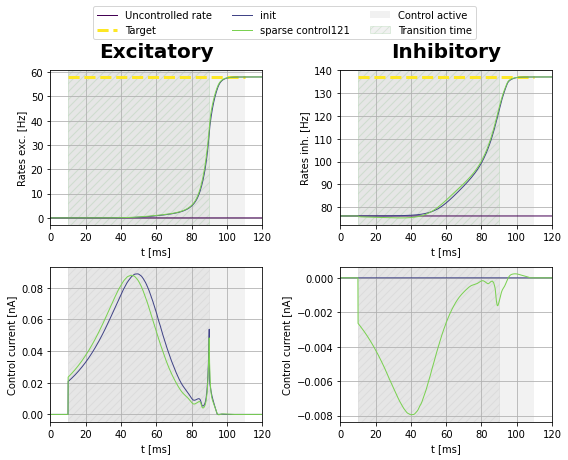

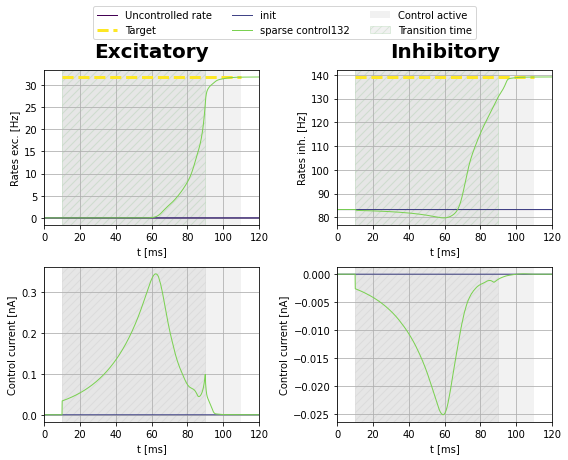

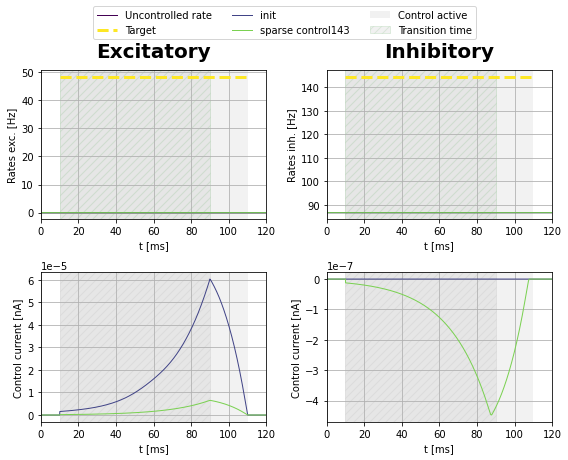

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  13055.235202935373
set cost params:  1.0 13055.235202935373 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13305.219132227821
Gradient descend method:  None
RUN  1 , total integrated cost =  13305.014760210754
RUN  2 , total integrated cost =  13305.014365986674
RUN  3 , total integrated cost =  13305.014364022101
RUN  4 , total integrated cost =  13305.014364006873
RUN  5 , total integrated cost =  13305.014364006753


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  13305.014364006745
RUN  7 , total integrated cost =  13305.014364006734
RUN  8 , total integrated cost =  13305.014364006734
Control only changes marginally.
RUN  8 , total integrated cost =  13305.014364006734
Improved over  8  iterations in  0.9775457326322794  seconds by  0.0015390067540579366  percent.
Problem in initial value trasfer:  Vmean_exc -56.672145630418136 -56.67215053024838
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  22854.26507319567
set cost params:  1.0 22854.26507319567 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21521.56852560934
Gradient descend method:  None
RUN  1 , total integrated cost =  21516.041413496714
RUN  2 , total integrated cost =  21516.01623864024
RUN  3 , total integrated cost =  21516.016206299515
RUN  4 , total integrated cost =  21516.01620568454
RUN  5 , total integrated cost =  21516.016205680906
RUN  6 , total integrated cost =  21516.01620568088
R

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  21516.016205680793
Control only changes marginally.
RUN  10 , total integrated cost =  21516.016205680793
Improved over  10  iterations in  1.0424365475773811  seconds by  0.025798862763821262  percent.
Problem in initial value trasfer:  Vmean_exc -56.698351290801824 -56.69835284312898
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  6577.595889823591
set cost params:  1.0 6577.595889823591 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21033.66048233523
Gradient descend method:  None
RUN  1 , total integrated cost =  21028.790127646876
RUN  2 , total integrated cost =  21028.777077678656
RUN  3 , total integrated cost =  21028.777070117332
RUN  4 , total integrated cost =  21028.777070103293
RUN  5 , total integrated cost =  21028.77707010326


...

RUN  1 , total integrated cost =  21065.935361255582
Control only changes marginally.
RUN  1 , total integrated cost =  21065.935361255582
Improved over  1  iterations in  0.2005931194871664  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69734242605469 -56.69734307165509
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
no convergence
weight =  6549.729620919216
set cost params:  1.0 6549.729620919216 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29121.350444595646
Gradient descend method:  None
RUN  1 , total integrated cost =  29121.35044459563


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  29121.35044459562
RUN  3 , total integrated cost =  29121.35044459562
Control only changes marginally.
RUN  3 , total integrated cost =  29121.35044459562
Improved over  3  iterations in  0.5357964970171452  seconds by  8.526512829121202e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.704199660443045 -56.704199120421094
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 8
[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, False], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged 

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  29121.35044459565
Control only changes marginally.
RUN  1 , total integrated cost =  29121.35044459565
Improved over  1  iterations in  0.20427905954420567  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.704199660443045 -56.704199120421094
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 9
[[True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  65.24942336105867
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1118173765057244
RUN  2 , total integrated cost =  1.0968338824591906
RUN  3 , total integrated cost =  1.0871586782310823
RUN  4 , total integrated cost =  1.0782413288619008
RUN  5 , total integrated cost =  1.0724326618282323
RUN  6 , total integrated cost =  1.0655126671548036
RUN  7 , total integrated cost =  1.0613793472276845
RUN  8 , total integrated cost =  1.05639918026787
RUN  9 , total integrated cost =  1.053854668345413
RUN  10 , total integrated cost =  1.0514251429880124
RUN  11 , total integrated cost =  1.0498789737527985
RUN  12 , total integrated cost =  1.0480820045626393
RUN  13 , total integrated cost =  1.046835606551801
RUN  14 , total integrated cost =  1.0467099972938507
RUN  15 , total integrated cost =  1.0465361179849615
R

ERROR:root:Problem in initial value trasfer


RUN  160 , total integrated cost =  1.0394251831636243
Control only changes marginally.
RUN  168 , total integrated cost =  1.0394251831635746
Improved over  168  iterations in  3.4827646128833294  seconds by  98.40699713557329  percent.
Problem in initial value trasfer:  Vmean_exc -56.672353229553615 -56.672353217873344
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  195.1180534624268
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0766623203755583
RUN  2 , total integrated cost =  1.0418179999961692
RUN  3 , total integrated cost =  1.0201777979158788
RUN  4 , total integrated cost =  1.0092129069587725
RUN  5 , total integrated cost =  1.0017698363748369
RUN  6 , total integrated cost =  0.9974744677707224
RUN  7 , total integrated cost =  0.9932552549602511
RUN  8 , total integrated cost =  0.9914828454139093
RUN  9 , total integrated cost =  0.988167798706642


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  173 , total integrated cost =  0.9748483740672425
Improved over  173  iterations in  3.688550941646099  seconds by  99.50038022788344  percent.
Problem in initial value trasfer:  Vmean_exc -56.698387716181884 -56.69838773771047
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  145.33747596648388
Gradient descend method:  None
RUN  1 , total integrated cost =  3.805575503465841
RUN  2 , total integrated cost =  3.6727324442938385
RUN  3 , total integrated cost =  3.5759857791501206
RUN  4 , total integrated cost =  3.5104329339851423
RUN  5 , total integrated cost =  3.4595002079888366
RUN  6 , total integrated cost =  3.426016976603546
RUN  7 , total integrated cost =  3.3975429981614487
RUN  8 , total integrated cost =  3.378952723360975
RUN  9 , total integrated cost =  3.3617154198747157
RUN  10 , total integrated cost =  3.3504460881839355
RUN 

...

RUN  2 , total integrated cost =  19226.098317129654
RUN  3 , total integrated cost =  19226.09831712965
RUN  4 , total integrated cost =  19226.09831712965
Control only changes marginally.
RUN  4 , total integrated cost =  19226.09831712965
Improved over  4  iterations in  0.11327693611383438  seconds by  5.466461061587324e-09  percent.
Problem in initial value trasfer:  Vmean_exc -75.49731634573835 -75.49733207088055
-------  121 0.5750000000000002 0.8250000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  307.8874528792081
Gradient descend method:  None
RUN  1 , total integrated cost =  3.0199470871294705
RUN  2 , total integrated cost =  3.000923708408193
RUN  3 , total integrated cost =  2.997754950293654
RUN  4 , total integrated cost =  2.9944620440132805
RUN  5 , total integrated cost =  2.992911375667942
RUN  6 , total integrated cost =  2.9913196643827793
RUN  7 , total integrated cost =  2.9905045307465024
RUN  8 

ERROR:root:Problem in initial value trasfer


RUN  150 , total integrated cost =  29.938860209848283
Control only changes marginally.
RUN  157 , total integrated cost =  29.933517337300007
Improved over  157  iterations in  3.3203285094350576  seconds by  37.933419512187825  percent.
Problem in initial value trasfer:  Vmean_exc -56.65233001704884 -56.652329986106935
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True


ERROR:root:Problem in initial value trasfer


RUN  0 , total integrated cost =  23430.76883648344
Gradient descend method:  None
RUN  1 , total integrated cost =  23430.76872642599
RUN  2 , total integrated cost =  23430.76872641117
RUN  3 , total integrated cost =  23430.768726411166
RUN  4 , total integrated cost =  23430.768726411163
RUN  5 , total integrated cost =  23430.76872641116
RUN  6 , total integrated cost =  23430.76872641116
Control only changes marginally.
RUN  6 , total integrated cost =  23430.76872641116
Improved over  6  iterations in  0.1657036915421486  seconds by  4.6977665135727875e-07  percent.
Problem in initial value trasfer:  Vmean_exc -73.80399221061195 -73.80415373105836


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0394251831635746
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0394251831635746
Control only changes marginally.
RUN  1 , total integrated cost =  1.0394251831635746
Improved over  1  iterations in  0.06277410499751568  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.672353229553615 -56.672353217873344
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9748483740672425
Gradient descend method:  None
RUN  1 , total integra

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.2649782897316513
Control only changes marginally.
RUN  1 , total integrated cost =  3.2649782897316513
Improved over  1  iterations in  0.06523564271628857  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69736163087634 -56.69736161371787
-------  44 0.47500000000000014 0.5750000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16137.019369149597
Gradient descend method:  None
RUN  1 , total integrated cost =  16137.019369149597
Control only changes marginally.
RUN  1 , total integrated cost =  16137.019369149597
Improved over  1  iterations in  0.05631156079471111  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.6874239024566 -73.6875918074978
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoi

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  19226.09831712965
Control only changes marginally.
RUN  1 , total integrated cost =  19226.09831712965
Improved over  1  iterations in  0.05443081259727478  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.49731634573835 -75.49733207088055
-------  121 0.5750000000000002 0.8250000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.9110911983725525
Gradient descend method:  None
RUN  1 , total integrated cost =  2.9110911983725525
Control only changes marginally.
RUN  1 , total integrated cost =  2.9110911983725525
Improved over  1  iterations in  0.06560985557734966  seconds by  0.0  percent.
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29.933517337300007
Gradient descend method:  None
RUN  1 , total integrated cost =  29.93351733

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23430.76872641116
Control only changes marginally.
RUN  1 , total integrated cost =  23430.76872641116
Improved over  1  iterations in  0.05699730105698109  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.80399221061195 -73.80415373105836
--------------- 10
[[True, True], [False, False], [False, False], [False, False], [False, False], [True, False], [False, False], [True, True], [False, False], [True, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  Tr

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
